## Compare PAE score to other mutation-based biomarker

In [1]:
import pandas as pd
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
from scipy.stats import wilcoxon
from scipy.stats import chi2_contingency
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')


Bad key text.latex.preview in file /home/lofa/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 123 ('text.latex.preview : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file /home/lofa/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 155 ('mathtext.fallback_to_cm : True  # When True, use symbols from the Computer Modern')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.5.3/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.jpeg_quality in file /home/lofa/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 418 ('savefig.jpeg_quality: 95       # when a jpeg is saved, the default quality para

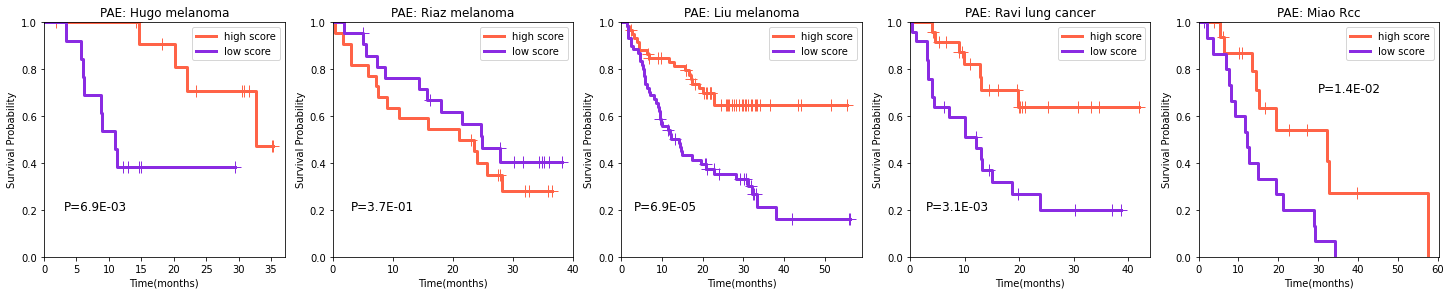

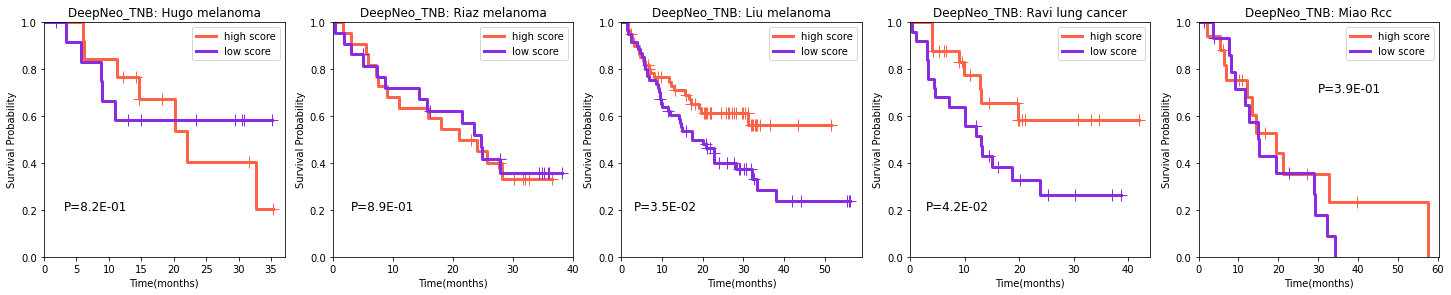

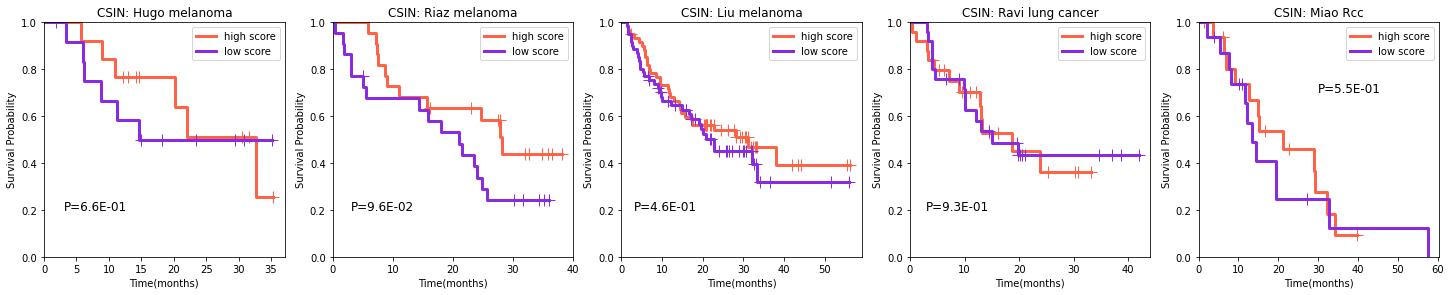

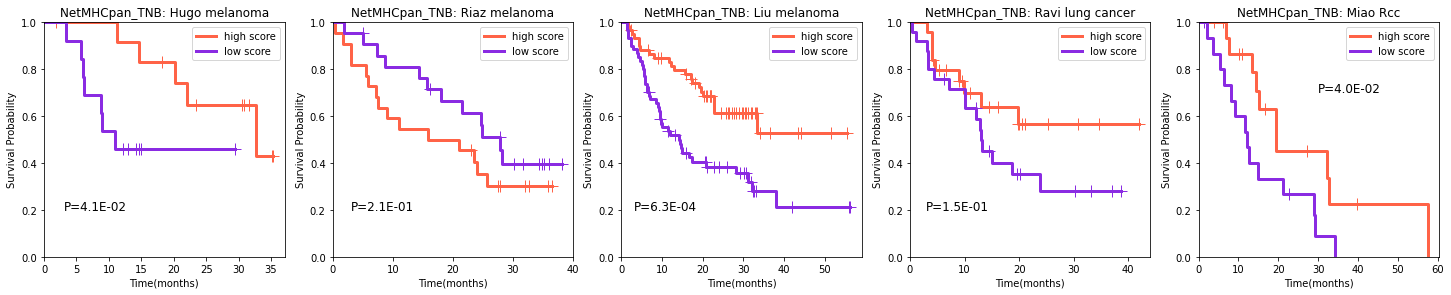

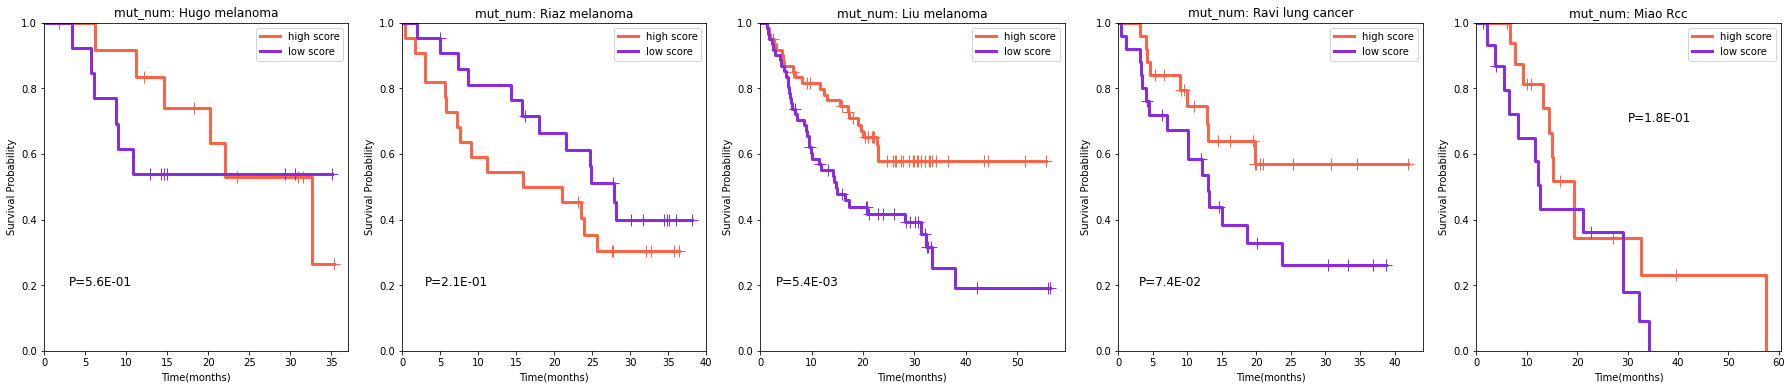

In [2]:
data = pd.read_csv('ICB_sample_information.csv')
datasets_list = ['Hugo melanoma', 'Riaz melanoma', 'Liu melanoma', 'Ravi lung cancer', 'Miao Rcc']
position = [[3, 0.2], [3, 0.2], [3, 0.2], [3, 0.2], [30, 0.7]]
for j, method in enumerate(['PAE', 'DeepNeo_TNB', 'CSIN', 'NetMHCpan_TNB', 'mut_num']):
    plt.figure(figsize=(25, 25))
    for i, dataset in enumerate(datasets_list):
        sur = data[data['dataset'] == dataset]
        sur['OS'] = sur['OS']/30
        sur.dropna(axis=0, inplace=True, how='any')
        sur.sort_values(method, inplace=True, ascending=True)
        sur['score'] = ['low score']*(int(sur.shape[0]/2)) + ['high score']*(sur.shape[0] - int(sur.shape[0]/2))
        dem = sur['score'] == 'low score'
        results = logrank_test(sur['OS'][dem], sur['OS'][~dem],
                               sur['dead'][dem], sur['dead'][~dem])
        p = format(results.p_value, '.1E')
        kmf = KaplanMeierFitter()
        color = {'low score':'#8a2be2', 'high score':'#ff6347'}
        ax = plt.subplot(5, 5, j*5 + i+1)
        for name, grouped_df in sur.groupby('score'):
            kmf.fit(grouped_df['OS'], grouped_df['dead'], label=name)
            kmf.plot_survival_function(ci_alpha=False, show_censors=True,
                                       linewidth=3, color=color[name])
        ax.text(position[i][0], position[i][1], f'P={p}', size=12)
        ax.set_title(f'{method}: {dataset}')
        ax.set_xlabel('Time(months)')
        ax.set_ylabel('Survival Probability')
        ax.set_ylim(0, 1)
        ax.set_xlim(0, )
plt.tight_layout()
plt.show()

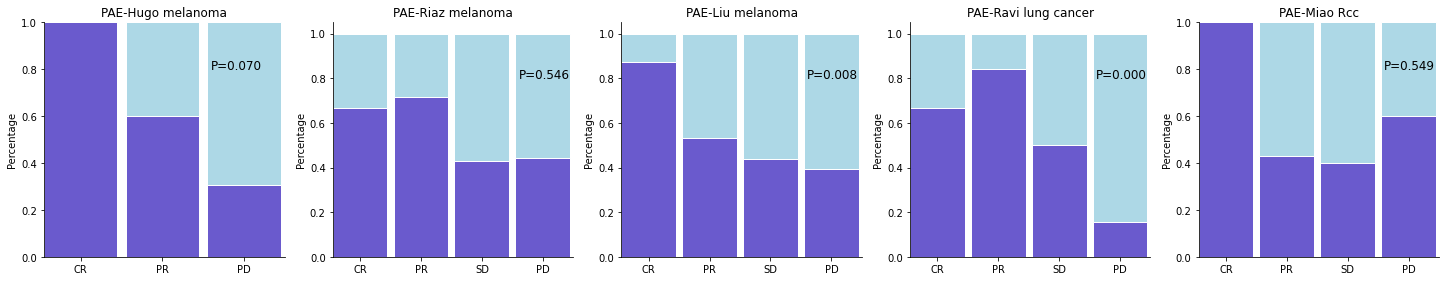

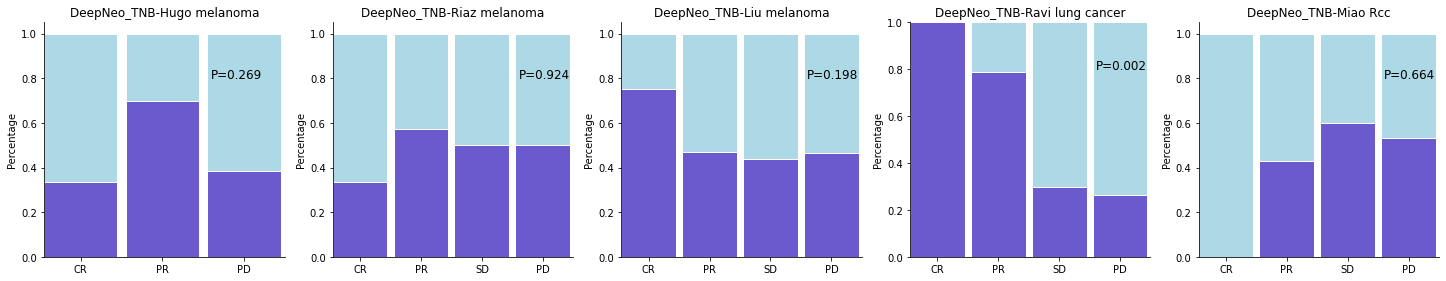

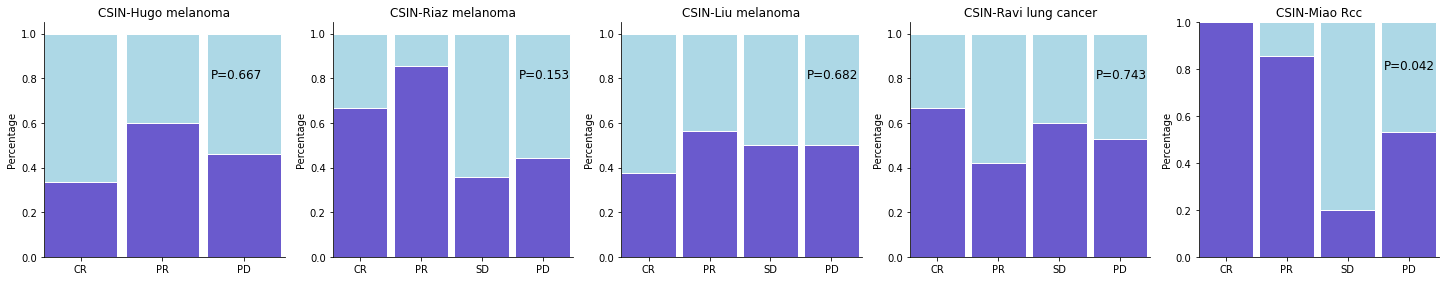

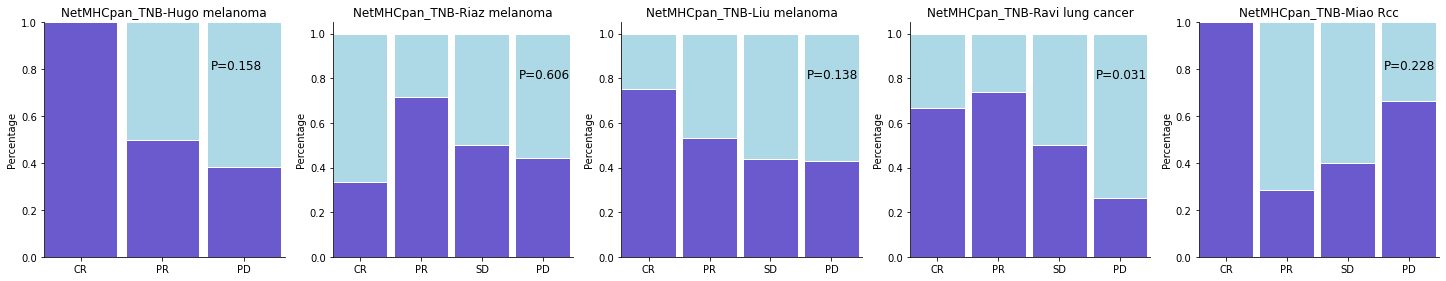

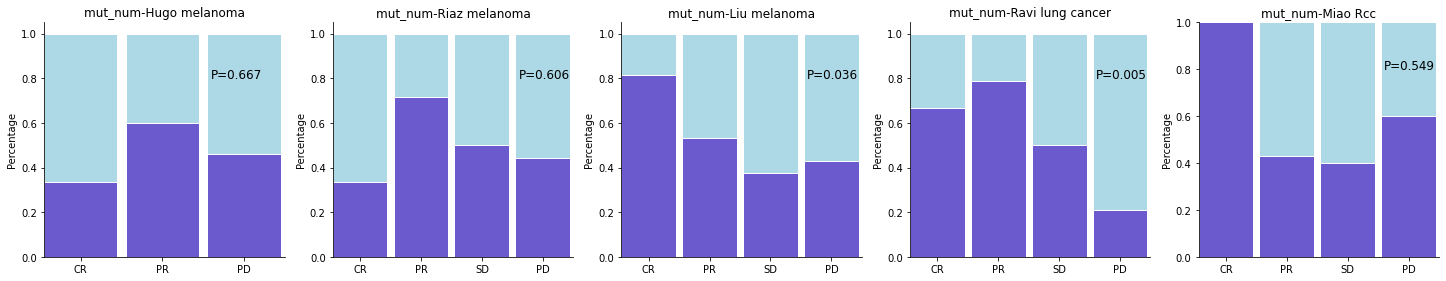

In [3]:
label_list = [['CR', 'PR', 'PD'], ['CR', 'PR', 'SD', 'PD'], ['CR', 'PR', 'SD', 'PD'], ['CR', 'PR', 'SD', 'PD'],
              ['CR', 'PR', 'SD', 'PD']]
for j, method in enumerate(['PAE', 'DeepNeo_TNB', 'CSIN', 'NetMHCpan_TNB', 'mut_num']):
    plt.figure(figsize=(25, 25))
    for i, dataset in enumerate(datasets_list):
        sur = data[data['dataset'] == dataset]
        sur = sur[sur['BR'].isin(label_list[i])]
        sur.sort_values(method, inplace=True, ascending=True)
        sur['TMB'] = ['low TMB']*(int(sur.shape[0]/2)) + ['high TMB']*(sur.shape[0] - int(sur.shape[0]/2))
        k = pd.DataFrame(sur.groupby('BR')['TMB'].value_counts())
        k. columns = ['number']
        k.reset_index(inplace=True)
        k = k.pivot(index='BR', columns='TMB', values='number')
        k = k.fillna(0)
        pvalue = chi2_contingency(k)[1]
        k = k.div(k.sum(axis=1), axis='rows')
        k = k.loc[label_list[i], :]
        percentages = np.array(k)
        labels = label_list[i]
        categories = ['high TMB', 'low TMB']
        ax = plt.subplot(5, 5, j*5+i+1)
        bottom = np.zeros(len(labels))
        colors = ['#6a5acd','#add8e6'] # 设置颜色调色板
        for k, category in enumerate(categories):
            ax.bar(labels, percentages[:, k], bottom=bottom, label=category, color=colors[k], edgecolor='white', width=0.9)
            bottom += percentages[:, k]# 设置图形属性
        #ax.set_xlabel('Labels')
        ax.text(len(label_list[i])-1.4, 0.8, f'P={pvalue:.3f}', size=12)
        ax.set_ylabel('Percentage')
        ax.set_title(f'{method}-{dataset}')
        ax.legend([])
        ax.get_legend().remove()
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_xlim(-0.45, len(label_list[i])-0.5)
plt.show()

In [4]:
sample_number = [14, 20, 70, 30, 20]
footstrap = []
for i in range(5000):
    for numb, dataset in enumerate(datasets_list):
        sur = data[data['dataset'] == dataset]
        sur.dropna(axis=0, inplace=True, how='any')
        part = sur.sample(n=sample_number[numb])
        foot = []
        for k, method in enumerate(['mut_num', 'PAE', 'NetMHCpan_TNB', 'DeepNeo_TNB', 'CSIN']):
            part.sort_values(method, inplace=True, ascending=True)
            part['score'] = ['low score']*(int(part.shape[0]/2)) + ['high score']*(int(part.shape[0]/2))
            dem = part['score'] == 'low score'
            results = logrank_test(part['OS'][dem], part['OS'][~dem], part['dead'][dem], part['dead'][~dem])
            p = format(results.p_value, '.1E')
            foot.append(p)
        foot.append(dataset)
        footstrap.append(foot)
footstrap_pd = pd.DataFrame(footstrap, columns=['mut_num', 'PAE', 'NetMHCpan_TNB', 'DeepNeo_TNB', 'CSIN', 'dataset'])
footstrap_long = footstrap_pd.melt(id_vars='dataset', value_name='value', var_name='method')
footstrap_long['value'] = footstrap_long['value'].astype('float')

In [5]:
pvalue_list = []
for dataset in datasets_list:
    for j in ['DeepNeo_TNB', 'CSIN', 'NetMHCpan_TNB', 'mut_num']:
        k = footstrap_long[footstrap_long['dataset'] == dataset]
        f = np.array(k[k['method'] == 'PAE']['value'].tolist())
        m = np.array(k[k['method'] == j]['value'].tolist())
        statistic, p_value = wilcoxon(f, m)
        pvalue_list.append([dataset, j, p_value])
pvalue_pd = pd.DataFrame(pvalue_list, columns=['dataset', 'method', 'pvalue'])

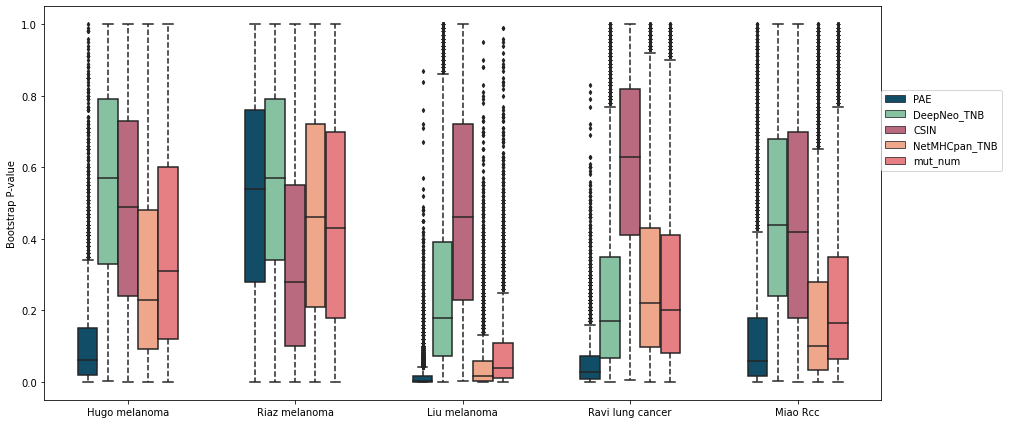

In [6]:
color_list = ['#045275', '#7ccba2', '#c65d78', '#ffa07a', '#f66e74']
fig = plt.figure(figsize=(14, 6))
ax = sns.boxplot(x='dataset', y='value', hue='method', width=0.6,
            palette=sns.color_palette(palette=color_list),
            hue_order=['PAE', 'DeepNeo_TNB', 'CSIN', 'NetMHCpan_TNB', 'mut_num'],
            data=footstrap_long, fliersize=3,
            whiskerprops={'linestyle':'--'})
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 0.8))
plt.xlabel('')
plt.ylabel('Bootstrap P-value')
plt.tight_layout()
plt.show()

In [7]:
sur = pd.read_csv('TCGA_sample_information.csv')
dead_pd = pd.DataFrame()
for x, y in sur.groupby('type'):
    dead_p = pd.DataFrame(y['dead'].value_counts())
    dead_p.columns = [x]
    dead_pd = pd.concat([dead_pd, dead_p], axis=1)
dead_pd.loc['ratio', :] = dead_pd.iloc[1, :]/dead_pd.iloc[0, :]
sur_100 = sur[sur['type'].isin(sur['type'].value_counts().index[sur['type'].value_counts()>=100])]
sur_100 = sur_100[sur_100['type'].isin(dead_pd.T.index[dead_pd.T['ratio']>0.1])]
cox_result = pd.DataFrame()
for i in sur_100['type'].value_counts().index:
    part = sur_100[sur_100['type'] == i]
    for method in ['PAE','CSIN','DeepNeo_TNB','NetMHCpan_TNB','mut_num']:
        part.sort_values(method, inplace=True, ascending=True)
        part[method] = [0]*(int(part.shape[0]/2)) + [1]*(part.shape[0] - int(part.shape[0]/2))
    part = part.loc[:, ['PAE','CSIN','DeepNeo_TNB','NetMHCpan_TNB','mut_num', 'OS', 'dead']]
    cph = CoxPHFitter()
    cph.fit(part, duration_col='OS', event_col='dead')
    resultp = cph.summary
    resultp['type'] = i
    resultp['method'] = resultp.index
    cox_result = pd.concat([cox_result, resultp], axis=0)
cox_result['type'] = pd.Categorical(cox_result['type'], categories=cox_result[cox_result['method'] == 'PAE'].sort_values('coef')['type'], ordered=True)
cox_result.sort_values('type', inplace=True)

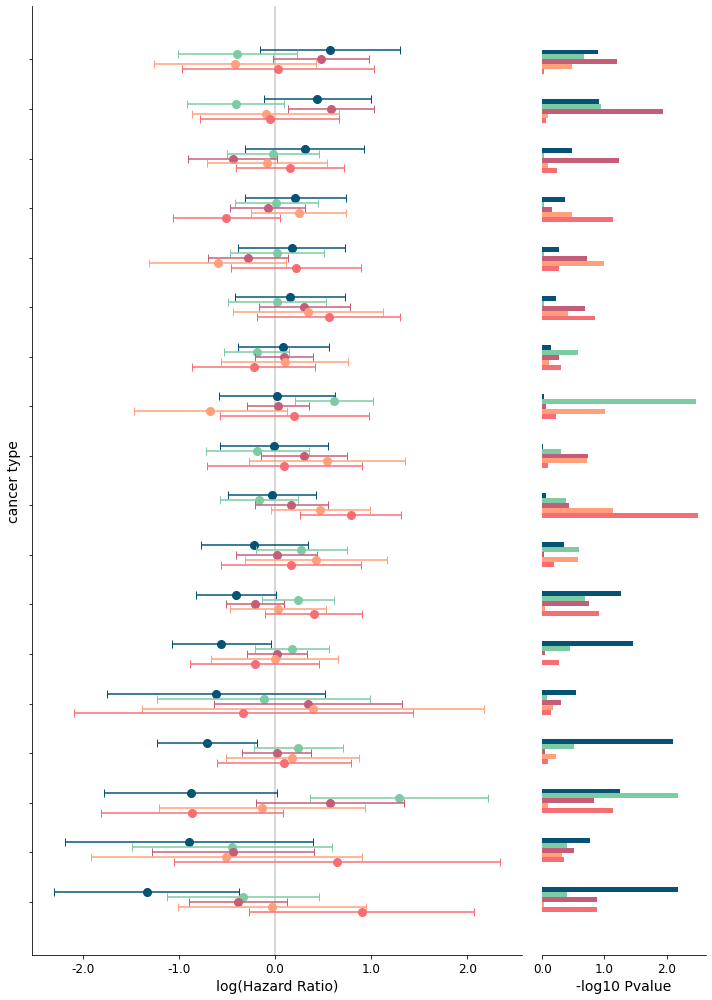

In [8]:
fig = plt.figure(figsize=(10,14))
gs = GridSpec(1, 2, width_ratios = [3, 1])
ax1 = fig.add_subplot(gs[0])
color_list = ['#045275', '#7ccba2', '#c65d78', '#ffa07a', '#f66e74']
for k, method in enumerate(['PAE','DeepNeo_TNB','CSIN','NetMHCpan_TNB','mut_num']):
    part = cox_result[cox_result['method'] == method]
    for i in range(part.shape[0]):
        ax1.plot(part['coef'][i], i-k*0.1, 'o', color=color_list[k], markersize=8)
        ax1.errorbar(part['coef'][i], i-k*0.1, xerr=[[part['coef'][i] - part['coef lower 95%'][i]],
                                               [[part['coef upper 95%'][i]] - part['coef'][i]]],
                     fmt='none', ecolor=color_list[k], capsize=4)
ax1.set_ylabel('cancer type', size=14)
ax1.set_xlabel('log(Hazard Ratio)', size=14)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_yticks(np.arange(18)-0.2)
ax1.set_xticklabels(ax1.get_xticks(), size=12)
ax1.set_yticklabels(cox_result[cox_result['method'] == 'CAP_MHCI_score']['type'], size=12)
ax1.axvline(0, color='grey', linestyle='-', alpha=0.4, zorder=0)

ax2 = fig.add_subplot(gs[1])
for k, method in enumerate(['PAE','DeepNeo_TNB','CSIN','NetMHCpan_TNB','mut_num']):
    part = cox_result[cox_result['method'] == method]
    part['logp'] = -np.log10(part['p'])
    ax2.barh(np.arange(18)-k*0.1, part['logp'], height=0.1, color=color_list[k])
ax2.set_xlabel('-log10 Pvalue', size=14)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.set_xticklabels(ax2.get_xticks(), size=12)
ax2.set_yticks([])
plt.subplots_adjust(wspace=0)
plt.tight_layout()
plt.show()

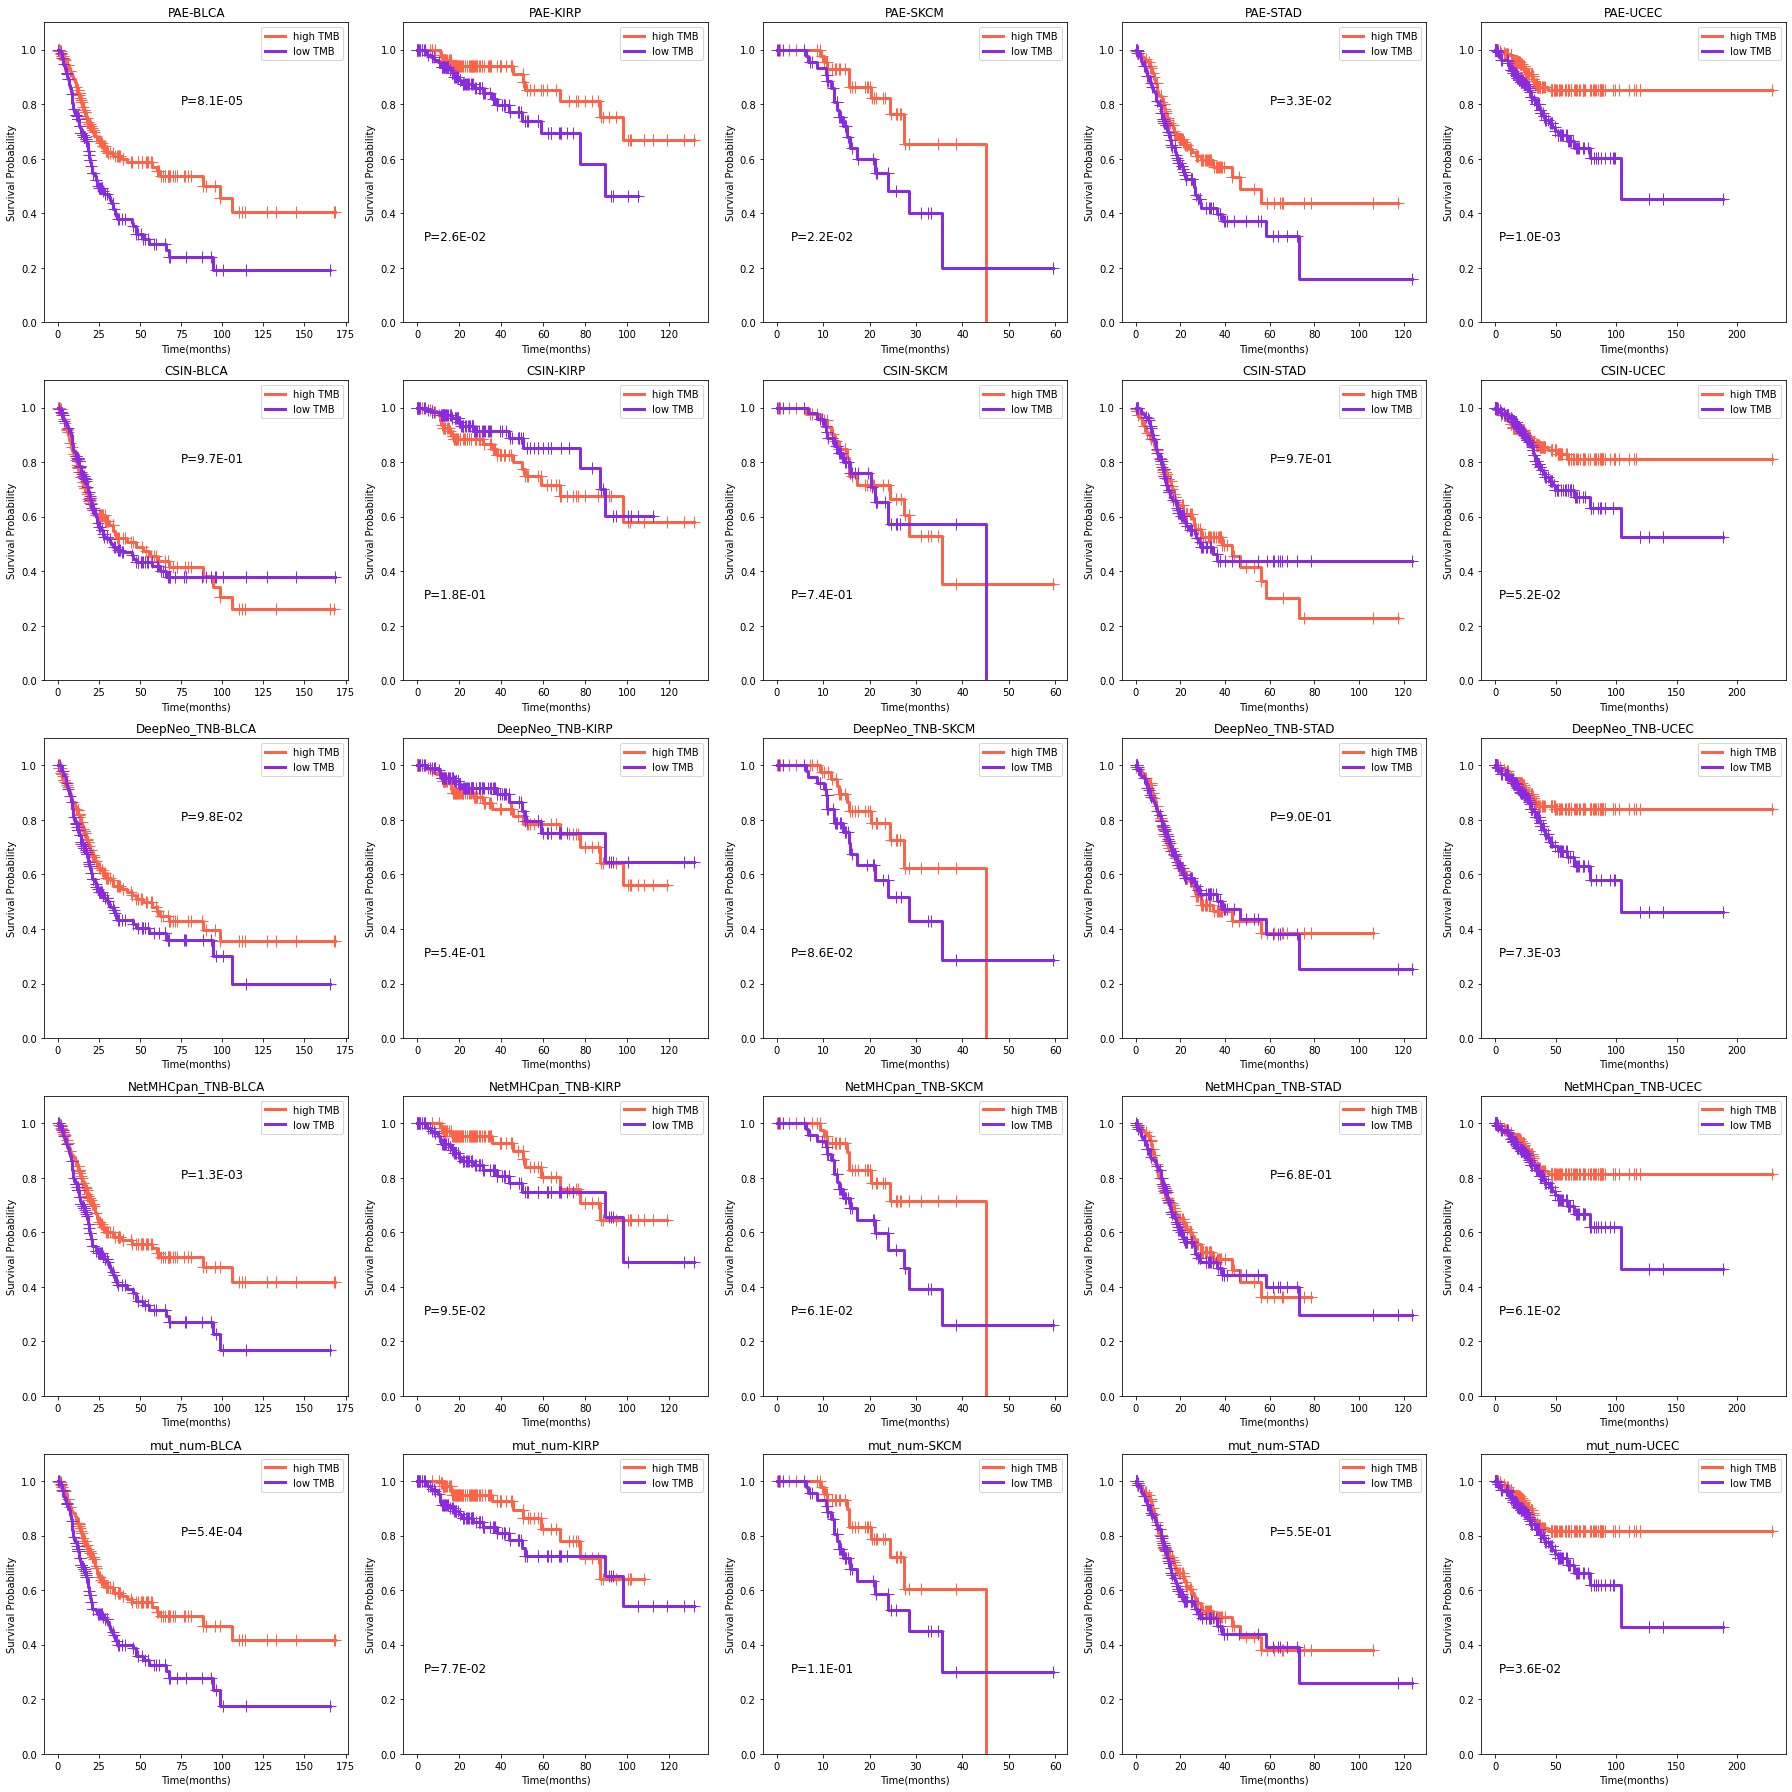

In [9]:
hot_list = [['BLCA',75, 0.8] , ['KIRP',3, 0.3] , ['SKCM',3, 0.3] , ['STAD', 60, 0.8],  ['UCEC',3, 0.3]]
plt.figure(figsize=(25, 25))
for j, method in enumerate(['PAE', 'CSIN', 'DeepNeo_TNB', 'NetMHCpan_TNB','mut_num']):  
    for i, tumor in enumerate(hot_list):
        x = sur_100[sur_100['type'] == hot_list[i][0]]
        x.sort_values(method, inplace=True, ascending=True)
        x['TMB'] = ['low TMB']*(int(x.shape[0]/2)) + ['high TMB']*(x.shape[0] - int(x.shape[0]/2))
        dem = x['TMB'] == 'low TMB'
        results = logrank_test(x['OS'][dem], x['OS'][~dem],
                               x['dead'][dem], x['dead'][~dem])
        p = format(results.p_value, '.1E')
        kmf = KaplanMeierFitter()
        color = {'low TMB':'#8a2be2', 'high TMB':'#ff6347'}
        ax = plt.subplot(5, 5, j*5 + i+1)
        for name, grouped_df in x.groupby('TMB'):
            kmf.fit(grouped_df['OS'], grouped_df['dead'], label=name)
        #    kmf.survival_function_
            kmf.plot_survival_function(ci_alpha=False, show_censors=True,
                                       linewidth=3, color=color[name])
        ax.text(hot_list[i][1], hot_list[i][2], f'P={p}', size=12)
        ax.set_title(f'{method}-{hot_list[i][0]}')
        ax.set_xlabel('Time(months)')
        ax.set_ylabel('Survival Probability')
        ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [10]:
tumor = ['BLCA', 'KIRP', 'SKCM', 'STAD', 'UCEC']
sample_number = [150, 150, 80, 150, 200]
footstrap = []
for i in range(5000):
    for numb, dataset in enumerate(tumor):
        sur = sur_100[sur_100['type'] == dataset]
        sur.dropna(axis=0, inplace=True, how='any')
        part = sur.sample(n=sample_number[numb])
        foot = []
        for k, method in enumerate(['mut_num', 'PAE', 'NetMHCpan_TNB', 'DeepNeo_TNB', 'CSIN']):
            part.sort_values(method, inplace=True, ascending=True)
            part['TNB'] = ['low TNB']*(int(part.shape[0]/2)) + ['high TNB']*(int(part.shape[0]/2))
            dem = part['TNB'] == 'low TNB'
            results = logrank_test(part['OS'][dem], part['OS'][~dem], part['dead'][dem], part['dead'][~dem])
            p = format(results.p_value, '.1E')
            foot.append(p)
        foot.append(dataset)
        footstrap.append(foot)
footstrap_pd = pd.DataFrame(footstrap, columns=['mut_num', 'PAE', 'NetMHCpan_TNB', 'DeepNeo_TNB', 'CSIN', 'dataset'])
footstrap_long = footstrap_pd.melt(id_vars='dataset', value_name='value', var_name='method' )
footstrap_long['value'] = footstrap_long['value'].astype('float')
pvalue_list = []
for dataset in tumor:
    for j in ['DeepNeo_TNB', 'CSIN', 'NetMHCpan_TNB', 'mut_num']:
        k = footstrap_long[footstrap_long['dataset'] == dataset]
        f = np.array(k[k['method'] == 'PAE']['value'].tolist())
        m = np.array(k[k['method'] == j]['value'].tolist())
        statistic, p_value = wilcoxon(f, m)
        pvalue_list.append([dataset, j, p_value])

In [12]:
pvalue_list

[['BLCA', 'DeepNeo_TNB', 0.0],
 ['BLCA', 'CSIN', 0.0],
 ['BLCA', 'NetMHCpan_TNB', 1.1841887972253369e-85],
 ['BLCA', 'mut_num', 2.0484069639885157e-09],
 ['KIRP', 'DeepNeo_TNB', 0.0],
 ['KIRP', 'CSIN', 0.0],
 ['KIRP', 'NetMHCpan_TNB', 0.0],
 ['KIRP', 'mut_num', 5.55004638007509e-207],
 ['SKCM', 'DeepNeo_TNB', 0.0],
 ['SKCM', 'CSIN', 0.0],
 ['SKCM', 'NetMHCpan_TNB', 0.0],
 ['SKCM', 'mut_num', 0.0],
 ['STAD', 'DeepNeo_TNB', 0.0],
 ['STAD', 'CSIN', 0.0],
 ['STAD', 'NetMHCpan_TNB', 0.0],
 ['STAD', 'mut_num', 0.0],
 ['UCEC', 'DeepNeo_TNB', 0.0],
 ['UCEC', 'CSIN', 0.0],
 ['UCEC', 'NetMHCpan_TNB', 0.0],
 ['UCEC', 'mut_num', 0.0]]

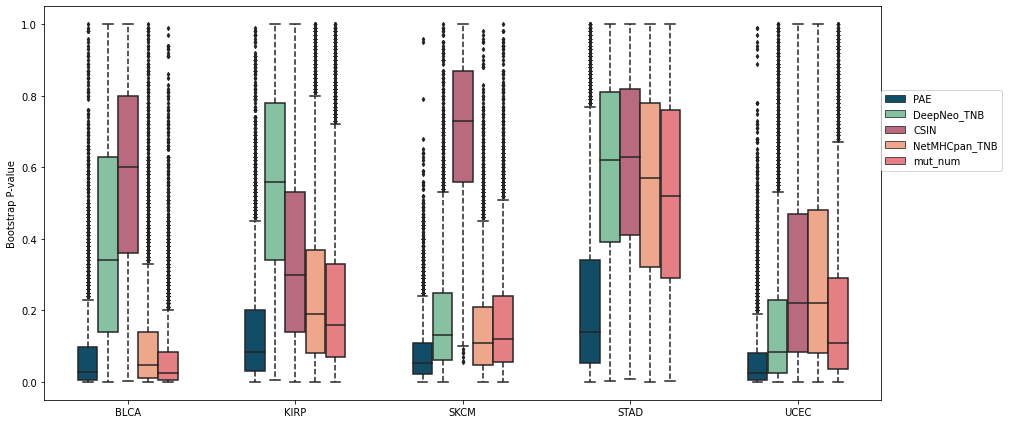

In [11]:
color_list = ['#045275', '#7ccba2', '#c65d78', '#ffa07a', '#f66e74']
fig = plt.figure(figsize=(14, 6))
ax = sns.boxplot(x='dataset', y='value', hue='method', width=0.6,
            palette=sns.color_palette(palette=color_list),
            hue_order=['PAE', 'DeepNeo_TNB', 'CSIN', 'NetMHCpan_TNB', 'mut_num'],
            data=footstrap_long, fliersize=3,
            whiskerprops={'linestyle':'--'})
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 0.8))
plt.xlabel('')
plt.ylabel('Bootstrap P-value')
plt.tight_layout()
plt.show()